In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from collections import Counter
import seaborn as sns
from matplotlib import pyplot as plt

import pickle
import glob
import os

In [2]:
from annot import *
from utils import get_annotation
annotationdf = get_annotation()

hPPIN_DE2
/Users/sharminm2/Dropbox/nih/context/plots/hPPIN_DE2/Fig_2b_geneset_folds.png


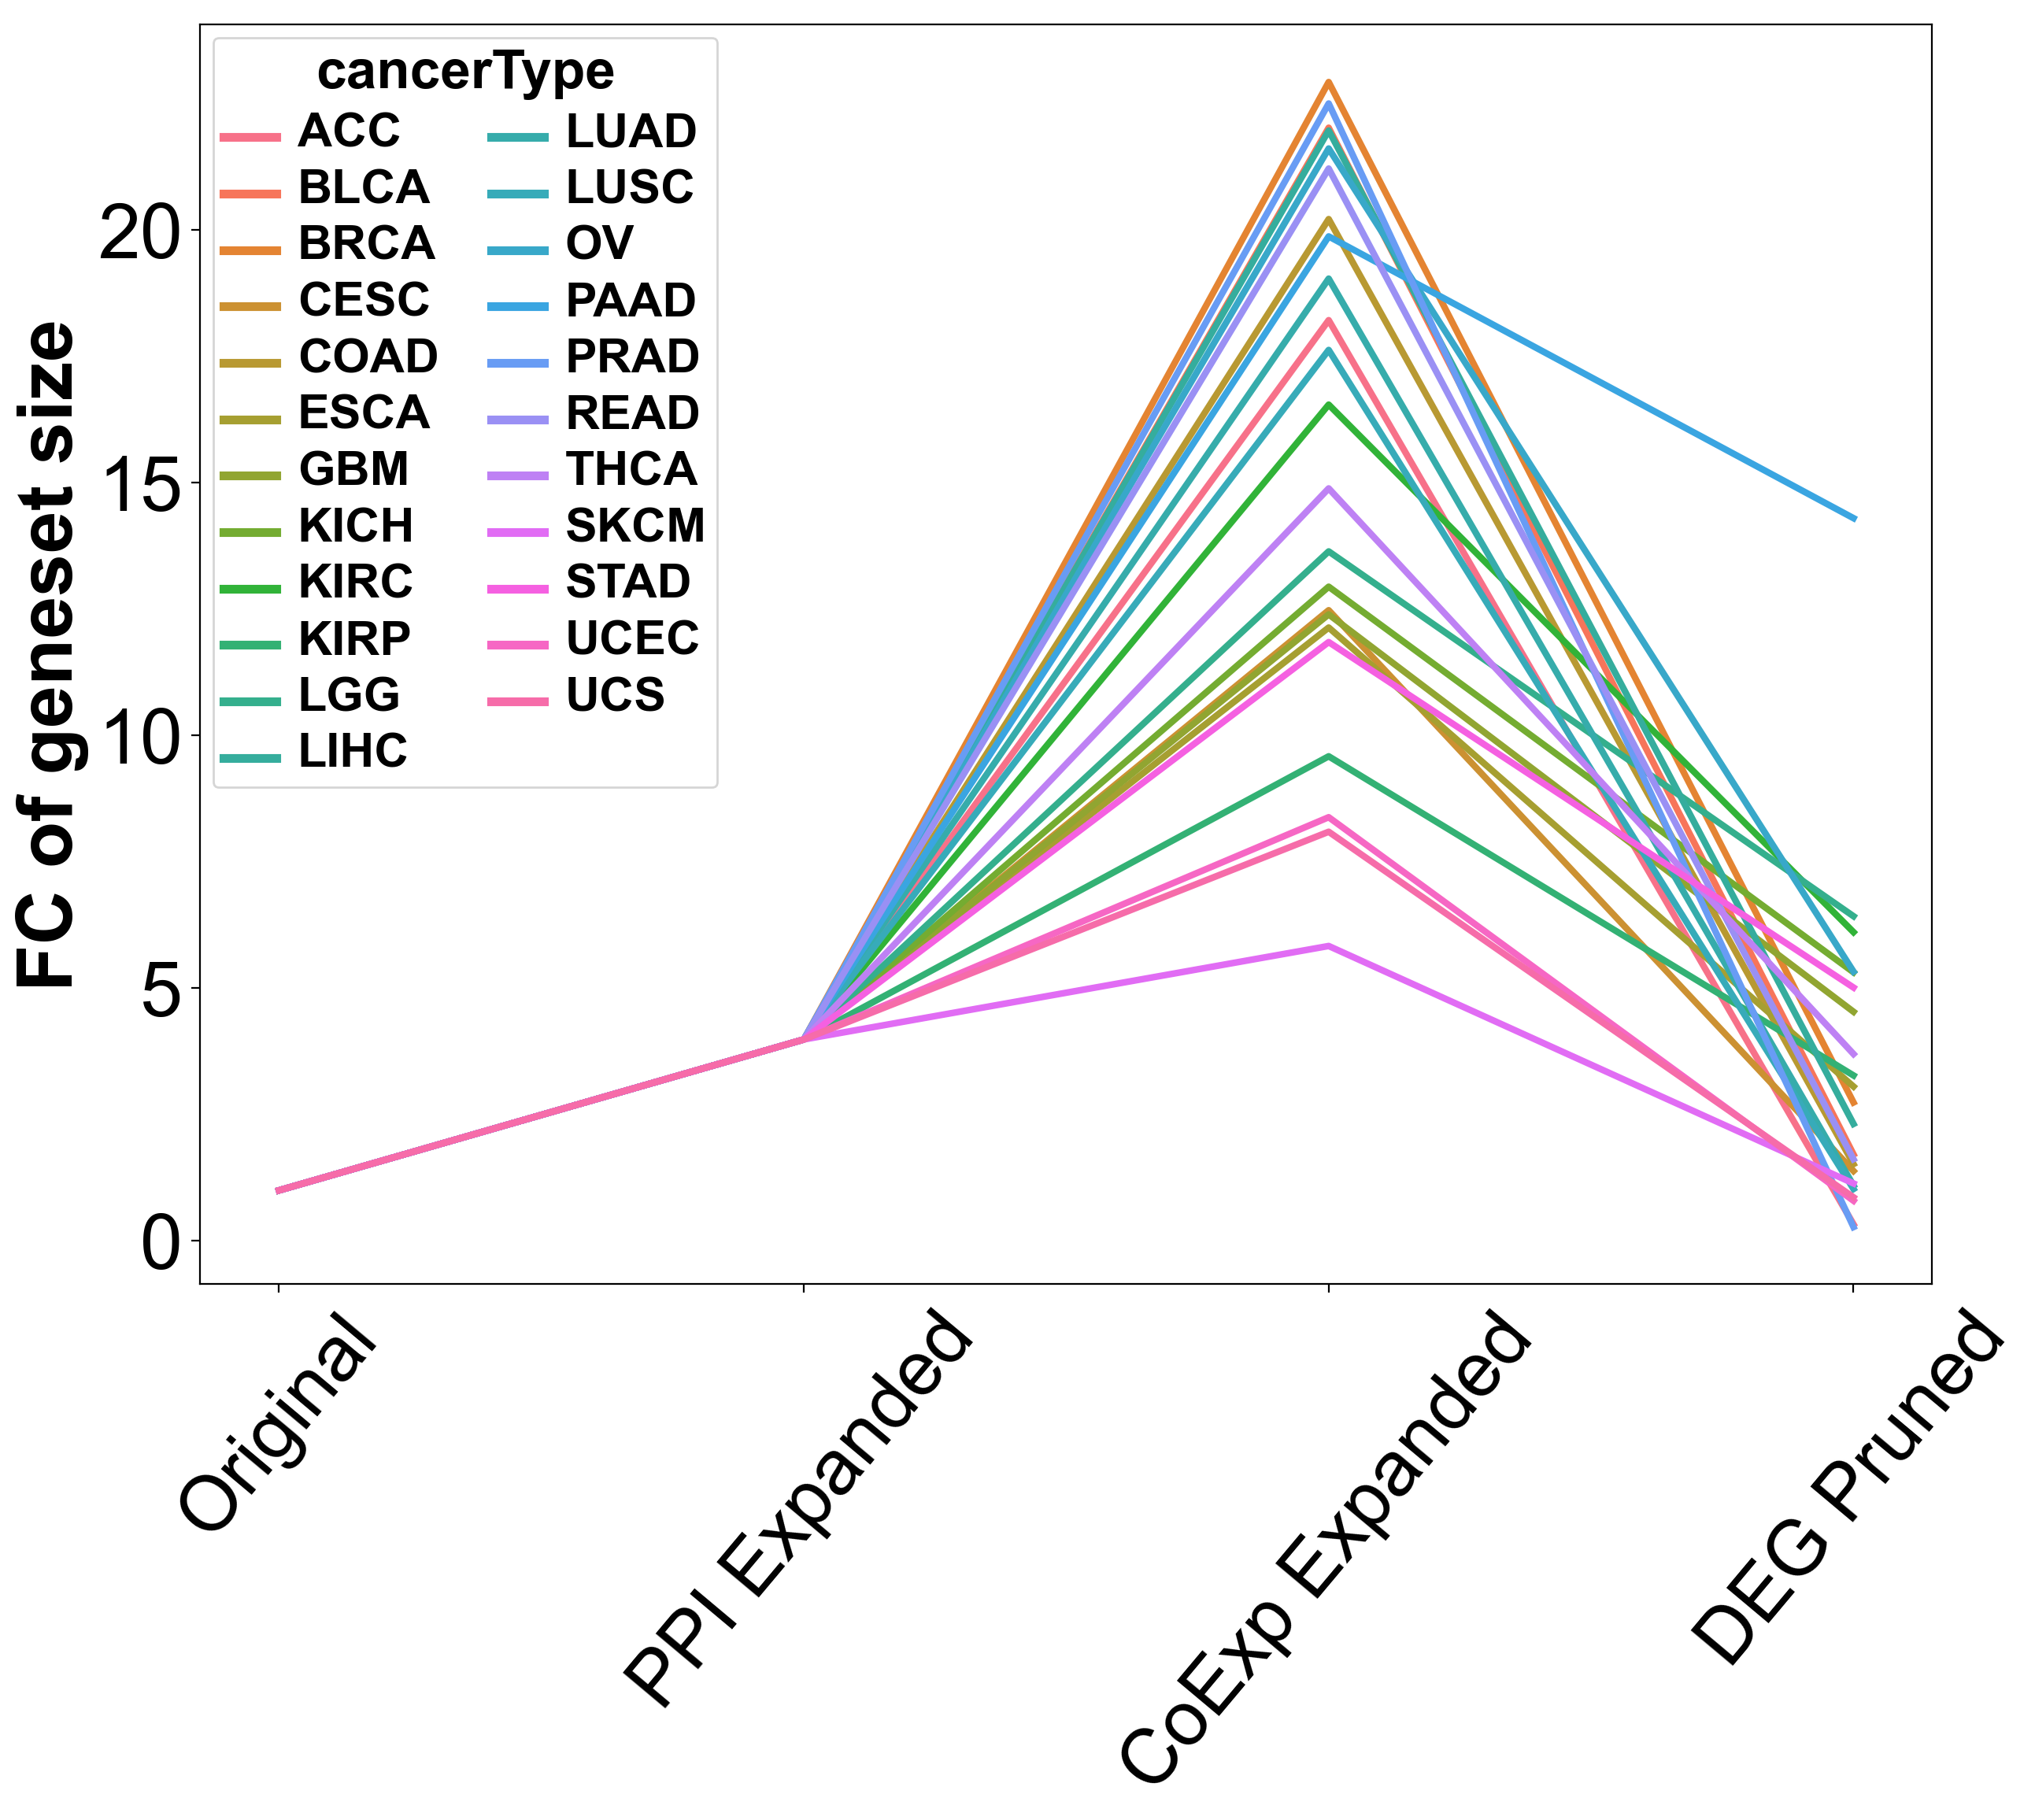

In [14]:
from manuscript import aggregate_FC_data, fig_2b_version3
from annot import *
df = aggregate_FC_data(annotationdf)

plot_FC_data_main(df[df['signature']=='Angiogenesis'], '2b_geneset_folds')
# fig_2b_version3(df[df['signature']!='Angiogenesis'], 'S1_geneset_folds')
# df[df['variable']=='DEG Pruned'].groupby('signature').apply(lambda x: np.var(x['value']))
# df

In [ ]:
from manuscript import fig_2b_version1_data, fig_2b_version3
from annot import *
# df = fig_2b_version1_data(annotationdf)
# fig_2b_version3(df[df['signature']=='Angiogenesis'], '2b_geneset_folds')
fig_2b_version3(df[df['signature']!='Angiogenesis'], 'S1_geneset_folds')
# df[df['variable']=='DEG Pruned'].groupby('signature').apply(lambda x: np.var(x['value']))
# df

In [ ]:
ji = pd.read_excel('/Users/sharminm2/Dropbox/nih/context/data/results/hPPIN_DE2/jaccard/Signature-Jaccard.xlsx', sheet_name=None)
a = ji['Angiogenesis']
b = a.where(np.triu(np.ones(a.shape), k=2).astype(np.bool))
b = b.stack().reset_index()
new_ji = dict()
for key in ji.keys():
    a = ji[key]
    b = a.where(np.triu(np.ones(a.shape), k=2).astype(np.bool))
    b = b.stack().reset_index()
    new_ji[key] = b[0].values
labels, data = new_ji.keys(), new_ji.values()

#fig, axes = plt.subplots(1, 1, figsize=(6,4), tight_layout=True, dpi=700) #
ax = pw.Brick(figsize=(6,4))
rc('font', weight='bold')
rcParams['text.latex.preamble'] = [r'\usepackage{sfmath} \boldmath']
sns.boxplot(ax=ax, data=pd.DataFrame.from_dict(new_ji))
ax.tick_params(axis='x', rotation=90)
ax.set_ylabel('Jaccard Indices', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.savefig(f'{PROJECT_location}/plots/{CUR_DST}/Fig_2c_JI.png')
# fig.savefig(f'{PROJECT_location}/plots/{CUR_DST}/Fig_2c_JI.png')

# 5A, S5: survival results

In [70]:
from manuscript import aggregate_survival_summary_data

df_top, x_df, y_df = aggregate_survival_summary_data(annotationdf, panel_option='top') #context vs original
df_de, x_df, y_df = aggregate_survival_summary_data(annotationdf, panel_option='de') #de vs original #why de should be 
df_dis, x_df, y_df = aggregate_survival_summary_data(annotationdf, panel_option='discard') #retained vs discarded
df_hpa, x_df, y_df = aggregate_survival_summary_data(annotationdf, panel_option='hpa') #context vs hpa
df_top, reference_df, context_df = cox_regression_summary_data(annotationdf, subType_option='BRCA', panel_option='top')

df_top.to_csv(f'{PROJECT_location}/survival/HR_summary_context_panel.csv', header=True, index=True)
df_de.to_csv(f'{PROJECT_location}/survival/HR_summary_de_panel.csv', header=True, index=True)
df_dis.to_csv(f'{PROJECT_location}/survival/HR_summary_discarded_genes_panel.csv', header=True, index=True)
df_hpa.to_csv(f'{PROJECT_location}/survival/HR_summary_hpa_panel.csv', header=True, index=True)
# df_dis

hPPIN_DE2


In [71]:
from scipy.stats import mannwhitneyu, wilcoxon
print(wilcoxon(y_df.melt()['value'].astype('float'), x_df.melt()['value'].astype('float'), alternative='greater'))


WilcoxonResult(statistic=29240.5, pvalue=0.009024630425717262)


# go to 3plots.R

# S7: brca subtypes

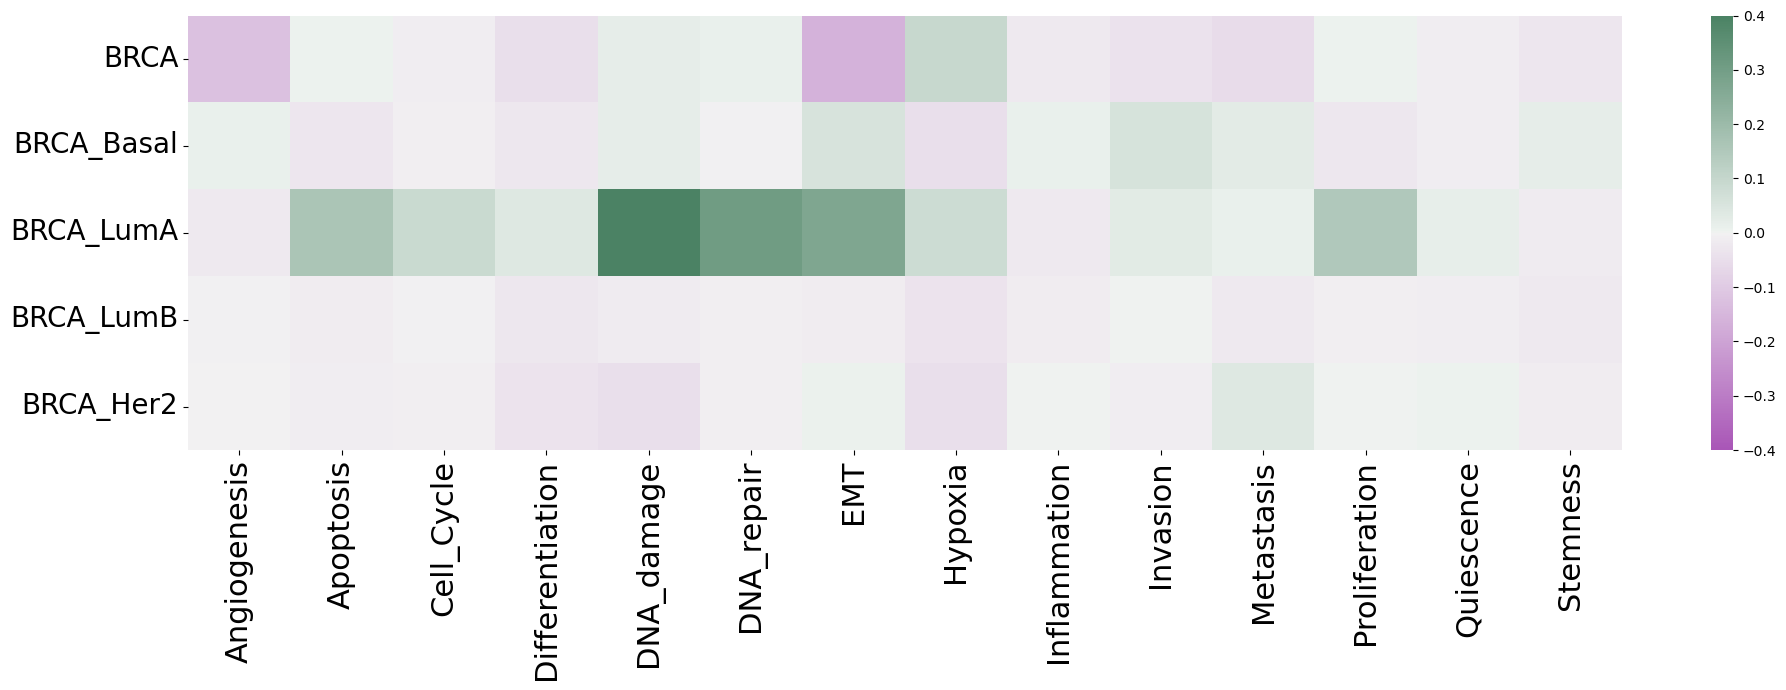

In [10]:
from manuscript import aggregate_survival_summary_data, plot_survival_supplementary

df, _, _ = aggregate_survival_summary_data(annotationdf, subType_option='BRCA', panel_option='top')
plot_survival_supplementary(df.T, 'S7_BRCAsubtypes', subType_option='BRCA')

# S6: ssgsea

In [108]:
# fig_ssgsea_scores('Neuroendocrine')
# fig, axes = plt.subplots(figsize=(12,10), nrows=2, ncols=2)
dfs = []
for cancerType in ['ACC', 'KICH', 'LGG']:
    df = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_ssgsea_summary_context_vs_original.xlsx", sheet_name=cancerType)
    df['Reference'] = -np.log10(df['pvalue_original'])
    df['Context-specific'] = -np.log10(df['pvalue_context'])
    df['cancerType'] = cancerType
    dfs.append(df)

df = pd.concat(dfs)
for i, subdf in df.groupby('cancerType'):
    res = ranksums(x=subdf['Context-specific'], y=subdf['Reference'], alternative='greater')
    print(i, res.pvalue)
    
# df = pd.melt(df, id_vars=['signature', 'cancerType'], value_vars=['Reference', 'Context-specific'], ignore_index=False)
# df = df.rename(columns={'variable': 'group'})
# df
# ax = axes[0,0]
# sns.boxplot(ax=ax, data=df, x="cancerType", y="value", hue='group')

# ax.set_ylabel("-log10(p)", fontsize=15, fontdict=dict(weight='bold'))
# ax.set_xlabel("")

dfs = []
for cancerType in ['ACC', 'KICH', 'LGG']:
    df = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_ssgsea_summary_context_vs_de.xlsx", sheet_name=cancerType)
    df['DE'] = -np.log10(df['pvalue_original'])
    df['Context-specific'] = -np.log10(df['pvalue_context'])
    df['cancerType'] = cancerType
    dfs.append(df)

df = pd.concat(dfs)
for i, subdf in df.groupby('cancerType'):
    res = ranksums(x=subdf['Context-specific'], y=subdf['DE'], alternative='greater')
    print(i, res.pvalue)
    
# df = pd.melt(df, id_vars=['signature', 'cancerType'], value_vars=['DE', 'Context-specific'], ignore_index=False)
# df = df.rename(columns={'variable': 'group'})
# ax = axes[0,1]
# sns.boxplot(ax=ax, data=df, x="cancerType", y="value", hue='group')
# ax.set_ylabel("-log10(p)", fontsize=15, fontdict=dict(weight='bold'))
# ax.set_xlabel("")

dfs = []
dfdict = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_ssgsea_summary_context_vs_original.xlsx", sheet_name=None)
for cancerType, df in dfdict.items(): 
    df['Reference'] = -np.log10(df['pvalue_original'])
    df['Context-specific'] = -np.log10(df['pvalue_context'])
    df['cancerType'] = cancerType
    dfs.append(df)

df = pd.concat(dfs)
    
df = df.loc[df['signature'].isin(['DNA_damage', 'DNA_repair', 'EMT']), :]
for i, subdf in df.groupby('signature'):
    res = ranksums(x=subdf['Context-specific'], y=subdf['Reference'], alternative='greater')
    print(i, res.pvalue)
# df = pd.melt(df, id_vars=['signature', 'cancerType'], value_vars=['Reference', 'Context-specific'], ignore_index=False)
# df = df.rename(columns={'variable': 'group'})
# ax = axes[1,0]
# sns.boxplot(ax=ax, data=df, x="signature", y="value", hue='group')
# ax.set_ylabel("-log10(p)", fontsize=15, fontdict=dict(weight='bold'))
# ax.set_xlabel("")

dfs = []
dfdict = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_ssgsea_summary_context_vs_de.xlsx", sheet_name=None)
for cancerType, df in dfdict.items(): 
    df['DE'] = -np.log10(df['pvalue_original'])
    df['Context-specific'] = -np.log10(df['pvalue_context'])
    df['cancerType'] = cancerType
    dfs.append(df)

df = pd.concat(dfs)
df = df.loc[df['signature'].isin(['DNA_damage', 'DNA_repair', 'EMT']), :]
for i, subdf in df.groupby('signature'):
    res = ranksums(x=subdf['Context-specific'], y=subdf['DE'], alternative='greater')
    print(i, res.pvalue)
# df = pd.melt(df, id_vars=['signature', 'cancerType'], value_vars=['DE', 'Context-specific'], ignore_index=False)
# df = df.rename(columns={'variable': 'group'})
# ax = axes[1,1]
# sns.boxplot(ax=ax, data=df, x="signature", y="value", hue='group')
# ax.set_ylabel("-log10(p)", fontsize=15, fontdict=dict(weight='bold'))
# ax.set_xlabel("")

# fig.savefig(f'{PROJECT_location}/plots/{CUR_DST}/Fig_S4_HRssGSEA.png')

ACC 0.010798436756481835
KICH 0.026815652926693558
LGG 0.012178957859018494
ACC 0.23112015111096007
KICH 0.3066303640392151
LGG 6.846261276352259e-05
DNA_damage 0.25825027460712735
DNA_repair 0.6890111344256367
EMT 0.23109393012693147
DNA_damage 0.3584923949606378
DNA_repair 0.35031852430066
EMT 0.18095780505936293


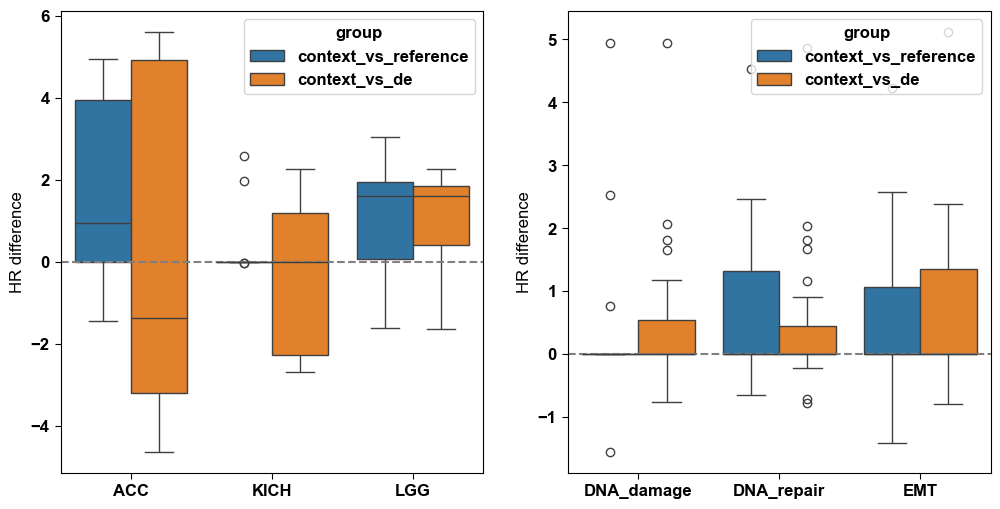

In [84]:
# read the ssgsea scores to do boxplots
fig, axes = plt.subplots(figsize=(12,6), nrows=1, ncols=2)
dfs_ref = []
dfs_de = []
for cancerType in ['ACC', 'KICH', 'LGG']:
    df = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_zssgsea_summary_context_vs_original.xlsx", sheet_name=cancerType)
    df['HR positives'] = df.apply(lambda x: diff(x), axis=1) #df['scores_context']-df['scores_original']
    df['cancerType'] = cancerType
    df['group'] = 'context_vs_reference'
    dfs_ref.append(df)

    df = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_zssgsea_summary_context_vs_de.xlsx", sheet_name=cancerType)
    df['HR positives'] = df.apply(lambda x: diff(x), axis=1) #df['scores_context']-df['scores_original']
    df['cancerType'] = cancerType
    df['group'] = 'context_vs_de'
    dfs_de.append(df)

df_ref = pd.concat(dfs_ref)
df_de = pd.concat(dfs_de)
df = pd.concat([df_ref, df_de], axis=0, ignore_index=True)
ax = axes[0]
sns.boxplot(ax=ax, data=df, x="cancerType", y="HR positives", hue='group')
ax.set_ylabel("HR difference")
ax.set_xlabel("")
ax.axhline(y=0, color='grey', linestyle='--')


dfs_ref = []
dfs_de = []
dfdict_ref = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_zssgsea_summary_context_vs_original.xlsx", sheet_name=None)
dfdict_de = pd.read_excel(f"{PROJECT_location}/data/results/{CUR_DST}/survival-age/joint_zssgsea_summary_context_vs_de.xlsx", sheet_name=None)
for cancerType, df in dfdict_ref.items(): 
    df['HR positives'] = df.apply(lambda x: diff(x), axis=1) # df['scores_context']-df['scores_original']
    df['cancerType'] = cancerType
    df['group'] = 'context_vs_reference'
    dfs_ref.append(df)

    df = dfdict_de[cancerType]
    df['HR positives'] = df.apply(lambda x: diff(x), axis=1) # df['scores_context']-df['scores_original']
    df['cancerType'] = cancerType
    df['group'] = 'context_vs_de'
    dfs_de.append(df)

df_ref = pd.concat(dfs_ref)
df_de = pd.concat(dfs_de)
df = pd.concat([df_ref, df_de], axis=0, ignore_index=True)
df = df.loc[df['signature'].isin(['DNA_damage', 'DNA_repair', 'EMT']), :]
ax = axes[1]
sns.boxplot(ax=ax, data=df, x="signature", y="HR positives", hue='group')
ax.set_ylabel("HR difference")
ax.set_xlabel("")
ax.axhline(y=0, color='grey', linestyle='--')

fig.savefig(f'{PROJECT_location}/plots/{CUR_DST}/Fig_S4_HRssGSEA2.png')

# 5B, S8: responder and non-responder samples

In [18]:
from ml import responder_status, test_responder_status, fig_responder_status
from context import read_genes
dfs = responder_status(annotationdf)

GSE21974
(19592, 19)
(19592, 40)
GSE25066
(11790, 90)
(11790, 250)
GSE123728
(784, 15)
(784, 11)
PRJEB23709
(18322, 20)
(18322, 18)


In [19]:
df = pd.concat(dfs, axis=0)
df.head()

from scipy.stats import mannwhitneyu, wilcoxon
print(wilcoxon(df['Context-specific'].astype('float'), df['DE'].astype('float'), alternative='greater'))
print(wilcoxon(df['Context-specific'].astype('float'), df['Context-agnostic'].astype('float'), alternative='greater'))
print(wilcoxon(df['Context-specific'].astype('float'), df['hpa'].astype('float'), alternative='greater'))
print(wilcoxon(df['Retained'].astype('float'), df['Discarded'].astype('float'), alternative='greater'))

WilcoxonResult(statistic=1125.0, pvalue=0.0038221591140210403)
WilcoxonResult(statistic=1266.0, pvalue=6.740115607910113e-05)
WilcoxonResult(statistic=1238.0, pvalue=0.00016589036254488715)
WilcoxonResult(statistic=1191.0, pvalue=0.0002098558558665357)


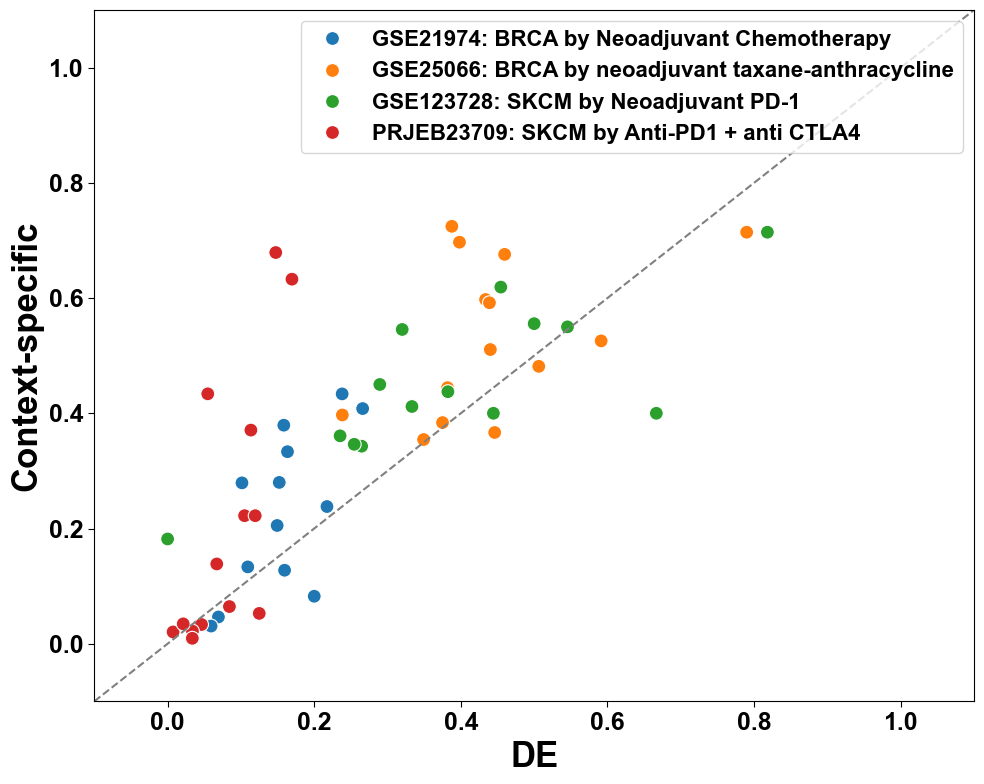

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10,8), tight_layout=True) #

ax = sns.scatterplot(ax=ax, data=df, x='Context-agnostic', y='Context-specific', hue='Dataset', s=100) 
ax.set_xlim((-0.1,1.1))
ax.set_ylim((-0.1,1.1))
ax.set_xlabel('DE', fontsize=25, fontweight='bold')
ax.set_ylabel('Context-specific', fontsize=25, fontweight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
plt.setp(ax.get_legend().get_texts(), fontsize='15', fontweight='bold') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18', fontweight='bold')
ax.axline((-0.1,-0.1), slope=1, color='grey', linestyle='--')
ax.legend(loc='upper right', prop={'weight': 'bold', 'size': 16})
fig.savefig(f'{PROJECT_location}/Figures/Fig_5B_therapy_response2.png')

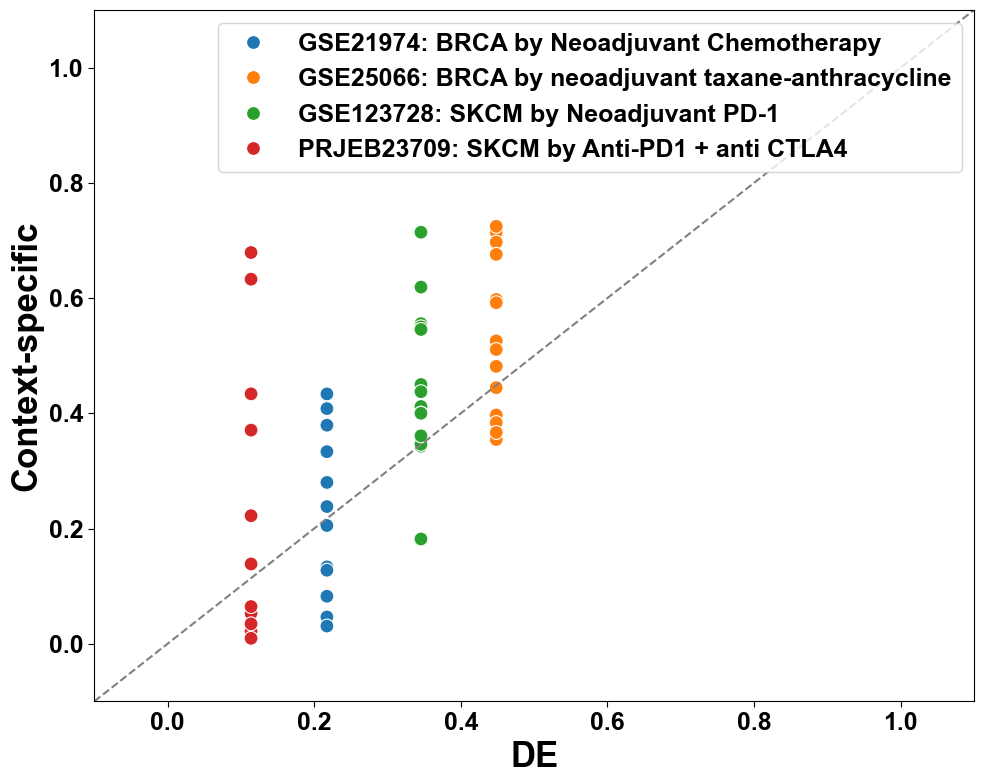

In [31]:

fig, ax = plt.subplots(1, 1, figsize=(10,8), tight_layout=True) #

ax = sns.scatterplot(ax=ax, data=df, x='DE', y='Context-specific', hue='Dataset', s=100) 
ax.set_xlim((-0.1,1.1))
ax.set_ylim((-0.1,1.1))
ax.set_xlabel('DE', fontsize=25, fontweight='bold')
ax.set_ylabel('Context-specific', fontsize=25, fontweight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
plt.setp(ax.get_legend().get_texts(), fontsize='15', fontweight='bold') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18', fontweight='bold')
ax.axline((-0.1,-0.1), slope=1, color='grey', linestyle='--')
ax.legend(loc='upper right', prop={'weight': 'bold', 'size': 18})
fig.savefig(f'{PROJECT_location}/Figures/Fig_S8A_therapy_response2.png')


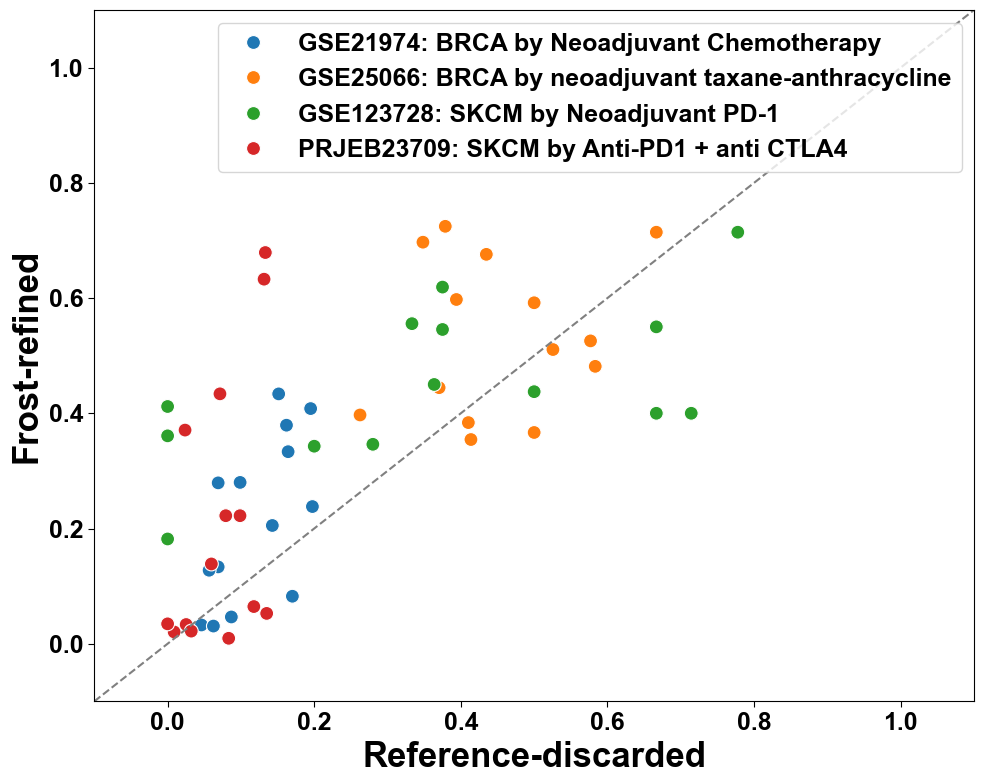

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(10,8), tight_layout=True) #

ax = sns.scatterplot(ax=ax, data=df, x='hpa', y='Context-specific', hue='Dataset', s=100)
ax.set_xlim((-0.1,1.1))
ax.set_ylim((-0.1,1.1))
ax.set_xlabel('Reference-discarded', fontsize=25, fontweight='bold')
ax.set_ylabel('Frost-refined', fontsize=25, fontweight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
plt.setp(ax.get_legend().get_texts(), fontsize='15', fontweight='bold') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18', fontweight='bold')
ax.axline((0,0), slope=1, color='grey', linestyle='--')
ax.legend(loc='upper right', prop={'weight': 'bold', 'size': 18})
fig.savefig(f'{PROJECT_location}/Figures/Fig_S8B_therapy_response2.png')


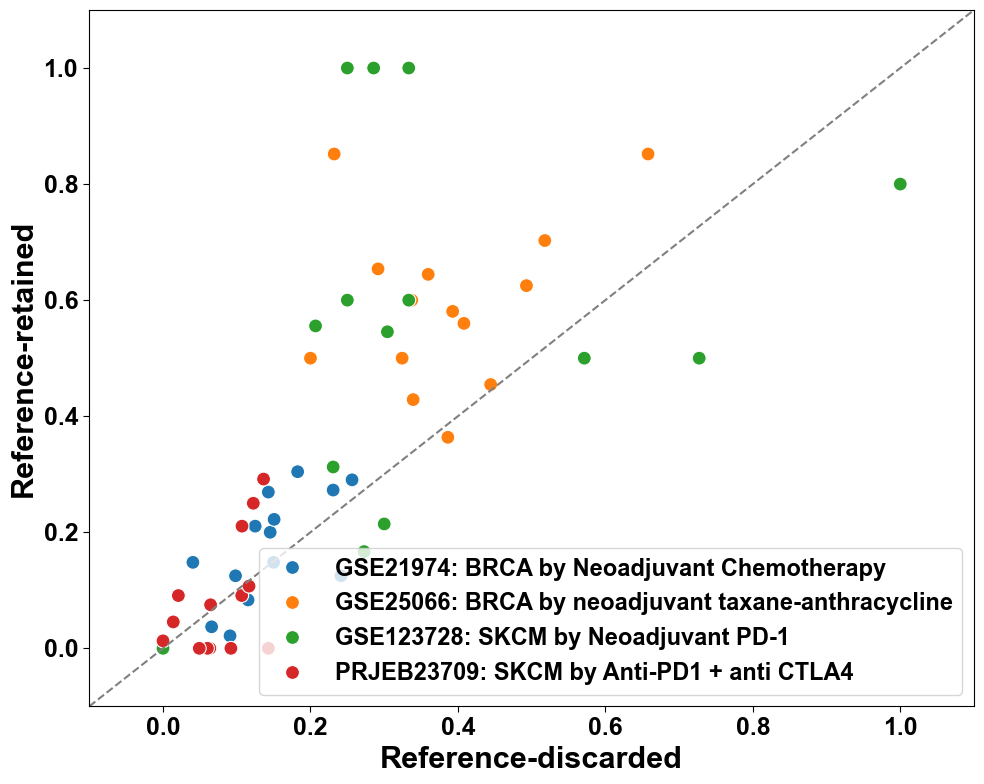

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10,8), tight_layout=True) #

ax = sns.scatterplot(ax=ax, data=df, x='Discarded', y='Retained', hue='Dataset', s=100, alpha=1)
ax.set_xlim((-0.1,1.1))
ax.set_ylim((-0.1,1.1))
ax.set_xlabel('Reference-discarded', fontsize=22, fontweight='bold')
ax.set_ylabel('Reference-retained', fontsize=22, fontweight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
plt.setp(ax.get_legend().get_texts(), fontsize='15') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18')
ax.axline((0,0), slope=1, color='grey', linestyle='--')
ax.legend(loc='lower right', prop={'weight': 'bold', 'size': 17})
fig.savefig(f'{PROJECT_location}/Figures/Fig_S8C_therapy_response2.png')



# Fig 5C

In [ ]:
#check pcr.R code for the heatmaps